<a href="https://colab.research.google.com/github/Ruturaj2472/LangGraph_Tavily_Agent/blob/main/LangGraph_Tavily_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph Agent: Tools, Memory, Routing and Human-in-the-Loop



**What this notebook builds, stage by stage**

1. **Single LLM agent**: one node, one LLM call.
2. **Tool-using agent**: the LLM decides when to call Tavily web search and loops back with the results.
3. **Agent with memory**: conversation state saved per `thread_id` with a checkpointer.
4. **Sentiment router**: an LLM classifies feedback with **structured output** (positive / negative / neutral) and routes it to a specialised response agent.
5. **Human-in-the-loop review**: replies to negative feedback pause with `interrupt()` for human approval, with state stored durably in **SQLite**.
6. **Evaluation**: routing accuracy measured on 30 labeled feedback examples.

In [1]:
!pip install -q langgraph langchain-openai openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 17.5 MB/s eta 0:00:00


In [2]:
# langchain-tavily replaces the deprecated TavilySearchResults from langchain_community
# langgraph-checkpoint-sqlite provides SqliteSaver for durable memory (Stage 5)
!pip install -q langchain-tavily langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 6.5 MB/s eta 0:00:00


In [3]:
import os
from google.colab import userdata
OpenAI_API = userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = OpenAI_API

## Single LLM Agent

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Begin by creating a StateGraph. A StateGraph object outlines the structure of the chatbot as a "state machine."
# We'll incorporate nodes to represent the LLM and the functions that the agent can invoke,
# while edges will define how the agent transitions between these functions.

class State(TypedDict):
    messages: Annotated[list, add_messages]

# Each node can receive the current State as input and output an update to the state.
graph_builder = StateGraph(State)

In [5]:
# Load the LLM
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

# Create LLM invoke function
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# Creating first node

graph_builder.add_node("chatbot", chatbot)

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever the node is used.

Observe that the node receives the current State as input and returns a dictionary with an updated "messages" list. This is the standard pattern for all LangGraph node functions.

The add_messages function in our State appends the LLM's response messages to the existing messages in the state.









In [6]:
# creating edges


graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [7]:
# Finally, to execute the graph, call the compile() method on the graph builder.
# This will prepare the graph for execution.
# This generates a CompiledGraph that can be invoked on our state, allowing us to execute the graph's defined workflow.
graph = graph_builder.compile()

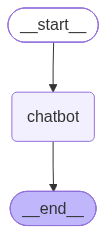

In [8]:
# Display the Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
# Passing a input to test the Agent

user_input = "What do you know about AI?"
print("User: " + user_input)

for event in graph.stream({"messages": [("user", user_input)]}):
  for value in event.values():
    print("Assistant:", value["messages"][-1].content)

User: What do you know about AI?
Assistant: Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are designed to think and act like humans. These systems can perform various tasks, including learning, reasoning, problem-solving, perception, language understanding, and more. Here are some key concepts related to AI:

1. **Types of AI**:
   - **Narrow AI**: Also known as weak AI, this type is designed to perform a specific task, such as image recognition or language translation. Most of the AI applications today fall under this category.
   - **General AI**: Also known as strong AI, this type would have the ability to understand, learn, and apply intelligence broadly, much like a human. General AI is still theoretical and has not yet been achieved.

2. **Machine Learning (ML)**: A subset of AI that uses statistical techniques to enable computers to improve their performance on a task through experience. Common methods include supervised learning, u

## Adding tools to this Simple Agent

We will be using the Tavily search engine through the `langchain-tavily` package. Get a Tavily API key from https://tavily.com/

In [10]:
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tools = [tool]

# Test the tool on its own before giving it to the agent
result = tool.invoke({"query": "What is ML?"})
for r in result["results"]:
    print(r["title"], "-", r["url"])

Machine learning - Wikipedia - https://en.wikipedia.org/wiki/Machine_learning
What is Machine Learning?  |  Google for Developers - https://developers.google.com/machine-learning/intro-to-ml/what-is-ml


In [12]:
from langgraph.prebuilt import ToolNode, tools_condition

# ToolNode -> A node that runs the tools called in the last AIMessage.
# It can be used either in StateGraph with a "messages" state key (or a custom key passed via ToolNode's 'messages_key').
# If multiple tool calls are requested, they will be run in parallel.
# The output will be a list of ToolMessages, one for each tool call.


# tools_condition -> Use in the conditional_edge to route to the ToolNode if the last message has tool calls.
# Otherwise, route to the end.

In [13]:
# New Agent

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearch(max_results=2)
tools = [tool]
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile()

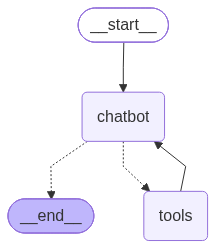

In [14]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### Testing the tool loop

The LLM decides for itself whether it needs the tool. A general-knowledge question is answered directly, while a question about recent events forces the agent to call Tavily and loop back with the results. The helper below prints every step, so the `chatbot -> tools -> chatbot` cycle is visible.

In [15]:
def run_agent(user_input, config=None):
    print(f"\n{'#' * 15} {user_input} {'#' * 15}")
    events = graph.stream({"messages": [("user", user_input)]}, config, stream_mode="values")
    tool_called = False
    for event in events:
        msg = event["messages"][-1]
        msg.pretty_print()
        if getattr(msg, "tool_calls", None):
            tool_called = True
    print(f"\n>> Tavily called: {tool_called}")

In [16]:
# General knowledge: the model answers on its own, no tool call expected
run_agent("What do you know about AI?")


############### What do you know about AI? ###############
================================ Human Message =================================

What do you know about AI?
================================== Ai Message ==================================

Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. Here are some key points about AI:

1. **Types of AI**:
   - **Narrow AI**: Also known as weak AI, this type is designed to perform a narrow task (e.g., facial recognition, internet searches).
   - **General AI**: Also known as strong AI, this type would outperform humans at nearly every cognitive task. It remains largely theoretical.

2. **Machine Learning**: A subset of AI that involves the use of algorithms and statistical models to enable machines to improve their performance on a task through experience.

3. **Deep Learning**: A further subset of machine learning that uses neural networks with man

In [17]:
# Recent events: the model cannot know this, so it should call Tavily
run_agent("What are the top AI news headlines this week?")


############### What are the top AI news headlines this week? ###############
================================ Human Message =================================

What are the top AI news headlines this week?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_CqLd0i86ELHxJxNUZoMvtooa)
 Call ID: call_CqLd0i86ELHxJxNUZoMvtooa
  Args:
    query: top AI news headlines
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "top AI news headlines", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://abcnews.com/Business/world-safer-ai-risk-after-trump-xi-summit/story?id=136818686", "title": "Is the world safer from AI risk after the Trump-Xi summit? - ABC News", "content": "Last week, OpenAI issued a statement calling for \"critical infrastructure operators and governments worldwide to establish secure 

## Add memory to the Agent


In [18]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

`MemorySaver` keeps everything in RAM, which is fine for experimentation but is lost when the kernel restarts. In production you would use `SqliteSaver` or `PostgresSaver` connected to your own database. Stage 5 below switches to `SqliteSaver`.

In [19]:
# Building the Agent with Memory

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearch(max_results=2)
tools = [tool]
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile(checkpointer=memory)

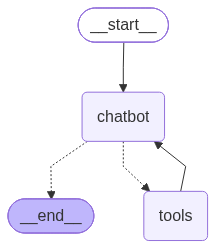

In [20]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [21]:
config = {"configurable": {"thread_id": "User_1"}}

user_input = "Hi, my name is Ruturaj"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Ruturaj
================================== Ai Message ==================================

Hello Ruturaj! How can I assist you today?


In [22]:
user_input = "Do you know my name?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you know my name?
================================== Ai Message ==================================

Yes, your name is Ruturaj. How can I help you today?


### What would happen if I change my config

In [23]:
config = {"configurable": {"thread_id": "User_2"}}

user_input = "Do you know my name?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you know my name?
================================== Ai Message ==================================

No, I don't know your name. You can share it with me if you'd like!


As expected, as the thread id has changed, it doesn't have access to memory of other thread

## Snapshot of current state

In [24]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Do you know my name?', additional_kwargs={}, response_metadata={}, id='797a377c-bf29-459b-bed5-bd08fd6bca35'), AIMessage(content="No, I don't know your name. You can share it with me if you'd like!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1193, 'total_tokens': 1212, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_cf2a139872', 'id': 'chatcmpl-EVUYkkj6XCvdmGeiC9uubIKfkbO8t', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a10a4f-84fe-7953-b7e9-ac8d36ce7e15-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1193, 'output_t

## Multi LLM Agent Flow (Sentiment Router)

One LLM classifies customer feedback, and a conditional edge routes it to a specialised response agent.

**Why structured output:** if the classifier returns free text, an answer like `"Positive."` or `"The sentiment is negative"` does not match the routing keys and the graph crashes. With `with_structured_output()` and a Pydantic schema using `Literal`, the model can only return one of the three valid labels, so routing is reliable. A **neutral** route handles questions and factual messages that are neither positive nor negative.

In [25]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# Create each LLM once, with an explicit model name, instead of inside every node
classifier_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
responder_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

# The schema restricts the classifier to exactly three labels
class SentimentResult(BaseModel):
    """Sentiment classification of a piece of customer feedback."""
    sentiment: Literal["positive", "negative", "neutral"] = Field(
        description=(
            "positive = the customer is clearly satisfied; "
            "negative = the customer is dissatisfied or complaining; "
            "neutral = a question, a factual statement, or no clear positive or negative emotion"
        )
    )

classify_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a sentiment analysis agent for customer feedback. "
     "Classify the feedback as positive, negative, or neutral. "
     "Sarcasm that expresses dissatisfaction counts as negative."),
    ("human", "Feedback: {input}"),
])

classify_chain = classify_prompt | classifier_llm.with_structured_output(SentimentResult)

In [26]:
class AgentState(TypedDict):
    input: str
    sentiment: str
    output: str

def classify_feedback(state):
    result = classify_chain.invoke({"input": state["input"]})
    return {"sentiment": result.sentiment}

def respond(instruction: str, feedback: str) -> str:
    prompt = f"{instruction}\n\nCustomer feedback: {feedback}\n\nWrite a short reply (2-3 sentences)."
    return responder_llm.invoke(prompt).content

def handle_positive_feedback(state):
    return {"output": respond("Thank the customer warmly for their positive feedback.", state["input"])}

def handle_negative_feedback(state):
    return {"output": respond("Apologize to the customer and assure them that the issue will be addressed.", state["input"])}

def handle_neutral_feedback(state):
    return {"output": respond("Acknowledge the customer's message politely and offer further help if needed.", state["input"])}

def route_by_sentiment(state) -> str:
    return state["sentiment"]

# Creating the workflow
workflow = StateGraph(AgentState)

workflow.add_node("classify", classify_feedback)
workflow.add_node("positive_agent", handle_positive_feedback)
workflow.add_node("negative_agent", handle_negative_feedback)
workflow.add_node("neutral_agent", handle_neutral_feedback)

workflow.add_edge(START, "classify")
workflow.add_conditional_edges(
    "classify",
    route_by_sentiment,
    {
        "positive": "positive_agent",
        "negative": "negative_agent",
        "neutral": "neutral_agent",
    },
)
for node in ["positive_agent", "negative_agent", "neutral_agent"]:
    workflow.add_edge(node, END)

# Save the compiled graph so we can actually run it
sentiment_app = workflow.compile()

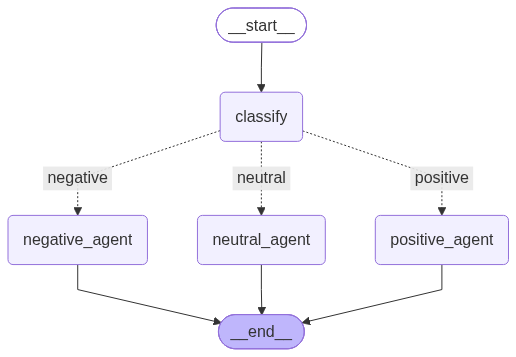

In [27]:
try:
    display(Image(sentiment_app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
user_inputs = [
    "I absolutely loved the service! The staff were friendly, and everything went smoothly. I'll definitely come back!",
    "The service was slow, and the staff seemed disinterested. I had to wait much longer than expected.",
    "My experience was frustrating. The website was hard to navigate, and I couldn't find the information I needed.",
    "Do you offer delivery on Sundays?",
]

for text in user_inputs:
    result = sentiment_app.invoke({"input": text})
    print(f"Feedback : {text}")
    print(f"Route    : {result['sentiment']}_agent")
    print(f"Reply    : {result['output']}\n")

Feedback : I absolutely loved the service! The staff were friendly, and everything went smoothly. I'll definitely come back!
Route    : positive_agent
Reply    : Thank you so much for your wonderful feedback! We're thrilled to hear that you enjoyed your experience and found our staff friendly. We can’t wait to welcome you back soon!

Feedback : The service was slow, and the staff seemed disinterested. I had to wait much longer than expected.
Route    : negative_agent
Reply    : Dear [Customer's Name],  
We sincerely apologize for the slow service and the lack of attentiveness you experienced during your visit. Your feedback is invaluable, and we will address these concerns with our team to ensure a better experience in the future. Thank you for bringing this to our attention.

Feedback : My experience was frustrating. The website was hard to navigate, and I couldn't find the information I needed.
Route    : negative_agent
Reply    : Dear Customer,  
I sincerely apologize for the frustr

## Human-in-the-Loop Review with Durable Memory

Replies to negative feedback are the riskiest to send automatically, so this graph **pauses before sending them** and waits for a human decision. Positive and neutral replies are sent automatically.

- `interrupt()` stops the graph inside the `human_review` node and returns the draft to the reviewer.
- The reviewer resumes the graph with `Command(resume=...)` and chooses **approve**, **edit** (supply a new reply), or **reject** (escalate to the support team).
- `SqliteSaver` writes every checkpoint to a SQLite file, so a paused review survives a restart. The demo below closes the database connection, reopens it, and shows the pending review is still there.

In [29]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt, Command

DB_PATH = "feedback_checkpoints.db"

# Start the demo with a fresh database so re-running the notebook gives clean results
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

class ReviewState(TypedDict):
    input: str
    sentiment: str
    draft: str
    output: str
    status: str

def positive_node(state):
    return {**handle_positive_feedback(state), "status": "auto-sent"}

def neutral_node(state):
    return {**handle_neutral_feedback(state), "status": "auto-sent"}

def draft_negative_reply(state):
    draft = respond("Apologize to the customer and assure them that the issue will be addressed.", state["input"])
    return {"draft": draft}

def human_review(state):
    # The graph pauses here. The dict is shown to the reviewer, and execution
    # resumes when the graph is invoked again with Command(resume=decision).
    decision = interrupt({
        "feedback": state["input"],
        "draft_reply": state["draft"],
        "options": "approve | edit (include 'reply') | reject",
    })
    action = decision.get("action")
    if action == "approve":
        return {"output": state["draft"], "status": "approved"}
    if action == "edit":
        return {"output": decision["reply"], "status": "edited by reviewer"}
    return {"output": "", "status": "rejected, escalated to support team"}

def build_review_graph(checkpointer):
    g = StateGraph(ReviewState)
    g.add_node("classify", classify_feedback)
    g.add_node("positive_agent", positive_node)
    g.add_node("neutral_agent", neutral_node)
    g.add_node("draft_negative", draft_negative_reply)
    g.add_node("human_review", human_review)

    g.add_edge(START, "classify")
    g.add_conditional_edges(
        "classify",
        route_by_sentiment,
        {"positive": "positive_agent", "neutral": "neutral_agent", "negative": "draft_negative"},
    )
    g.add_edge("draft_negative", "human_review")
    for node in ["positive_agent", "neutral_agent", "human_review"]:
        g.add_edge(node, END)
    return g.compile(checkpointer=checkpointer)

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
review_app = build_review_graph(SqliteSaver(conn))

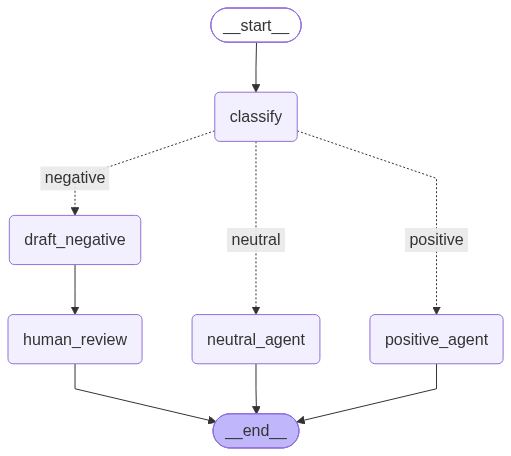

In [30]:
try:
    display(Image(review_app.get_graph().draw_mermaid_png()))
except Exception:
    pass

### 1. Negative feedback pauses for review

In [31]:
config_101 = {"configurable": {"thread_id": "ticket_101"}}

result = review_app.invoke(
    {"input": "My order arrived broken and nobody answered my emails for a week."},
    config_101,
)

if "__interrupt__" in result:
    pending = result["__interrupt__"][0].value
    print("PAUSED for human review")
    print("Feedback   :", pending["feedback"])
    print("Draft reply:", pending["draft_reply"])

print("Next node  :", review_app.get_state(config_101).next)

PAUSED for human review
Feedback   : My order arrived broken and nobody answered my emails for a week.
Draft reply: Dear [Customer's Name], 

I sincerely apologize for the inconvenience you've experienced with your order and for the delay in our response. Please rest assured that we are addressing this issue promptly and will ensure that it is resolved to your satisfaction. Thank you for your patience. 

Best regards,  
[Your Name]  
[Your Position]  
Next node  : ('human_review',)


### 2. The paused review survives a restart

We close the SQLite connection and rebuild the graph from scratch, as if the server had restarted. The pending review and its draft are loaded back from disk.

In [32]:
conn.close()

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
review_app = build_review_graph(SqliteSaver(conn))

restored = review_app.get_state(config_101)
print("Next node after restart:", restored.next)
print("Draft restored from SQLite:", restored.values["draft"])

Next node after restart: ('human_review',)
Draft restored from SQLite: Dear [Customer's Name], 

I sincerely apologize for the inconvenience you've experienced with your order and for the delay in our response. Please rest assured that we are addressing this issue promptly and will ensure that it is resolved to your satisfaction. Thank you for your patience. 

Best regards,  
[Your Name]  
[Your Position]  


### 3. The reviewer approves the draft

In [33]:
final = review_app.invoke(Command(resume={"action": "approve"}), config_101)
print("Status:", final["status"])
print("Sent  :", final["output"])

Status: approved
Sent  : Dear [Customer's Name], 

I sincerely apologize for the inconvenience you've experienced with your order and for the delay in our response. Please rest assured that we are addressing this issue promptly and will ensure that it is resolved to your satisfaction. Thank you for your patience. 

Best regards,  
[Your Name]  
[Your Position]  


### 4. The reviewer edits a draft before sending

In [34]:
config_102 = {"configurable": {"thread_id": "ticket_102"}}

result = review_app.invoke(
    {"input": "I was charged twice for the same order and still have no refund."},
    config_102,
)
print("Draft reply:", result["__interrupt__"][0].value["draft_reply"])

final = review_app.invoke(
    Command(resume={
        "action": "edit",
        "reply": "We're sorry about the double charge. A refund for the duplicate payment has been issued "
                 "and should appear within 3-5 business days.",
    }),
    config_102,
)
print("\nStatus:", final["status"])
print("Sent  :", final["output"])

Draft reply: Dear [Customer's Name], 

I sincerely apologize for the inconvenience you've experienced with being charged twice for your order. Please rest assured that we are looking into this issue and will ensure that your refund is processed promptly. Thank you for your patience. 

Best regards,  
[Your Name]  
[Your Position]  

Status: edited by reviewer
Sent  : We're sorry about the double charge. A refund for the duplicate payment has been issued and should appear within 3-5 business days.


### 5. Positive feedback is sent without pausing

In [35]:
config_103 = {"configurable": {"thread_id": "ticket_103"}}

result = review_app.invoke({"input": "The support team fixed my issue in minutes. Great job!"}, config_103)
print("Paused:", "__interrupt__" in result)
print("Status:", result["status"])
print("Sent  :", result["output"])

Paused: False
Status: auto-sent
Sent  : Thank you so much for your kind words! We're thrilled to hear that our support team was able to resolve your issue quickly. Your satisfaction means a lot to us!


## Evaluating the Router

Routing is only as good as the classifier, so we measure it on 30 hand-labeled feedback examples (10 per class). A few are deliberately harder: sarcasm (*"Oh great, another hour on hold"*) and understatement (*"Not bad at all"*).

Because `route_by_sentiment` maps each label to exactly one node, the classifier's label is the route the graph takes, so classifier accuracy equals routing accuracy.

In [36]:
eval_set = [
    # positive
    ("The delivery was faster than promised and the packaging was perfect.", "positive"),
    ("Customer support solved my problem in five minutes. Impressive!", "positive"),
    ("I've been using this app for a year and it keeps getting better.", "positive"),
    ("Great value for the price, I'd recommend it to friends.", "positive"),
    ("The staff went out of their way to help my elderly mother. Thank you!", "positive"),
    ("Checkout was smooth and the confirmation email came instantly.", "positive"),
    ("Honestly didn't expect much, but it exceeded my expectations.", "positive"),
    ("Five stars. Will order again.", "positive"),
    ("The new update fixed every issue I had reported. Nice work.", "positive"),
    ("Not bad at all, actually one of the better experiences I've had.", "positive"),
    # negative
    ("My package arrived two weeks late and the box was crushed.", "negative"),
    ("I was charged twice and still haven't received a refund.", "negative"),
    ("The app crashes every time I try to upload a photo.", "negative"),
    ("Support kept transferring me and nobody could answer my question.", "negative"),
    ("The product stopped working after three days.", "negative"),
    ("Oh great, another hour on hold. Fantastic service as always.", "negative"),
    ("I expected much more given the price.", "negative"),
    ("The website kept logging me out in the middle of checkout.", "negative"),
    ("Wow, they really managed to lose my order twice. Impressive.", "negative"),
    ("I won't be coming back.", "negative"),
    # neutral
    ("I ordered on Monday and it arrived on Thursday.", "neutral"),
    ("Do you ship to Canada?", "neutral"),
    ("What are your opening hours on weekends?", "neutral"),
    ("I'd like to change the email address on my account.", "neutral"),
    ("The product comes in three colors.", "neutral"),
    ("I received the invoice for order #4521.", "neutral"),
    ("Is there a student discount available?", "neutral"),
    ("I picked up my order from the store this afternoon.", "neutral"),
    ("Can I return an item without the original receipt?", "neutral"),
    ("I used the service for the first time today.", "neutral"),
]
print(len(eval_set), "labeled examples")

30 labeled examples


In [37]:
import pandas as pd

rows = []
for text, expected in eval_set:
    predicted = classify_chain.invoke({"input": text}).sentiment
    rows.append({"feedback": text, "expected": expected, "predicted": predicted,
                 "correct": predicted == expected})

results = pd.DataFrame(rows)

print(f"Routing accuracy: {results['correct'].mean():.1%} "
      f"({results['correct'].sum()}/{len(results)})\n")

print("Accuracy per class:")
print(results.groupby("expected")["correct"].mean().map("{:.0%}".format), "\n")

print("Confusion matrix (rows = expected, columns = predicted):")
print(pd.crosstab(results["expected"], results["predicted"]), "\n")

errors = results[~results["correct"]]
if errors.empty:
    print("No misrouted examples.")
else:
    print("Misrouted examples:")
    for _, r in errors.iterrows():
        print(f"- [{r['expected']} -> {r['predicted']}] {r['feedback']}")

Routing accuracy: 100.0% (30/30)

Accuracy per class:
expected
negative    100%
neutral     100%
positive    100%
Name: correct, dtype: object 

Confusion matrix (rows = expected, columns = predicted):
predicted  negative  neutral  positive
expected                              
negative         10        0         0
neutral           0       10         0
positive          0        0        10 

No misrouted examples.


## Summary

- **Tool use:** the agent calls Tavily only when it needs current information, and loops back with the results.
- **Memory:** conversation state is isolated per `thread_id`.
- **Reliable routing:** structured output guarantees the classifier returns a valid route, including a neutral path.
- **Human-in-the-loop:** negative-feedback replies pause for approve / edit / reject, and paused reviews survive restarts through `SqliteSaver`.
- **Evaluation:** routing accuracy is measured on a 30-example labeled set, with a confusion matrix and the misrouted examples listed.